# RoomBeacon — Data Engineering, EDA & Feature Engineering

This notebook is a reproducible data-engineering workflow for RoomBeacon latest-state listings.
It produces an auditable, feature-ready handoff; it deliberately stops before modeling because no
approved prediction target or split policy exists yet.


## 01. Problem & Data Understanding


### 01.1 Problem definition

Multi-source crawler data has different coverage and parser quality. The engineering task is to retain
raw traceability while producing a row-preserving, validated analytical dataset.


### 01.2 Objective and success criteria

**Objective:** profile raw quality, apply explicit cleaning rules, and publish feature metadata.

**Success:** one latest row per listing, immutable raw input, no row loss during cleaning, before/after
evidence for key fields, and no infinite feature values.


### 01.3 Unit of observation, target and assumptions

- **Unit:** one `rental_post_id` at its most recent observation.
- **Target:** not defined. No train/test split, target-driven feature selection, or modeling occurs here.
- **Assumptions:** price is VND/month, area is m², and location mappings with multiple candidates remain ambiguous.


## 02. Environment & Reproducibility


### 02.1 Project path and runtime environment


In [64]:
import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from utils import setup_project_path
except ModuleNotFoundError:
    from notebooks.utils import setup_project_path

PROJECT_ROOT = setup_project_path()
NOTEBOOKS_ROOT = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "data" / ".cache" / "matplotlib"))


Đã phát hiện thư mục gốc của dự án RoomBeacon: /mnt/Data/projects/roombeacon


'/mnt/Data/projects/roombeacon/data/.cache/matplotlib'

### 02.2 Library imports


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import Markdown, display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

load_dotenv(PROJECT_ROOT / ".env", override=False)


True

### 02.3 Project utilities


In [66]:
from analytics.duckdb.connection import create_analytics_connection
from utils.address_cleaner import clean_address
from utils.area_validator import MAX_AREA_M2, MIN_AREA_M2, classify_area_band, validate_area
from utils.location_normalizer import normalize_location
from utils.price_validator import MAX_PRICE_VND, MIN_PRICE_VND, classify_price_band, validate_price


### 02.4 Global configuration


In [67]:
RANDOM_SEED = 42
CLEANING_RULE_VERSION = "eda-prep-v1.0"
PALETTE = {"raw": "#C75B5B", "clean": "#2A9D8F", "neutral": "#457B9D"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


### 02.5 Data lineage


In [68]:
pipeline_nodes = [
    ("Bronze MySQL", "immutable observations"),
    ("DuckDB latest state", "one row / listing"),
    ("df_raw", "read-only audit input"),
    ("df_clean", "row-preserving clean data"),
    ("df_feature_ready", "handoff dataset"),
]


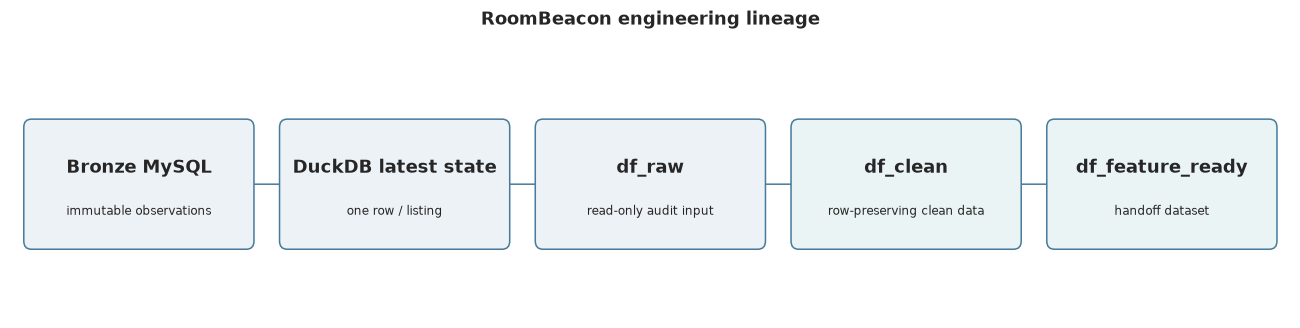

In [69]:
figure, axis = plt.subplots(figsize=(15, 3.2))
axis.set(xlim=(0, len(pipeline_nodes)), ylim=(0, 1))
axis.axis("off")

for index, (title, subtitle) in enumerate(pipeline_nodes):
    x_position = index + 0.08
    axis.add_patch(FancyBboxPatch((x_position, 0.28), 0.84, 0.42, boxstyle="round,pad=0.03", facecolor="#EAF4F4" if index >= 3 else "#EDF2F7", edgecolor="#457B9D"))
    axis.text(x_position + 0.42, 0.55, title, ha="center", va="center", weight="bold")
    axis.text(x_position + 0.42, 0.39, subtitle, ha="center", va="center", fontsize=8)
    if index < len(pipeline_nodes) - 1:
        axis.add_patch(FancyArrowPatch((x_position + 0.86, 0.49), (x_position + 1.05, 0.49), arrowstyle="->", mutation_scale=14, color="#457B9D"))

axis.set_title("RoomBeacon engineering lineage", pad=14)
plt.show()


## 03. Data Ingestion


### 03.1 Query path and input contract


In [70]:
EDA_QUERY_PATH = PROJECT_ROOT / "notebooks" / "sql" / "eda_latest_posts.sql"
REQUIRED_INPUT_COLUMNS = {
    "source", "rental_post_id", "listing_id", "title_raw", "url", "price", "area", "address",
    "full_address_inherited", "observed_at", "first_observed_at", "last_observed_at", "active_days",
}
OPTIONAL_INPUT_COLUMNS = {"latitude", "longitude"}


### 03.2 Load raw latest-state data


In [71]:
eda_query = EDA_QUERY_PATH.read_text(encoding="utf-8")
analytics_connection = create_analytics_connection()
df_raw = analytics_connection.sql(eda_query).df()
print(f"Loaded {len(df_raw):,} latest-state listings")


Loaded 47,753 latest-state listings


### 03.3 Validate schema and identity


In [72]:
missing_columns = REQUIRED_INPUT_COLUMNS.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f"EDA query missing required columns: {sorted(missing_columns)}")
if df_raw.empty:
    raise ValueError("EDA query returned no rows; check Bronze MySQL and DuckDB attachment.")
if df_raw["rental_post_id"].isna().any() or df_raw["rental_post_id"].duplicated().any():
    raise ValueError("Data contract violated: rental_post_id must be present and unique.")
print("✓ Schema and latest-listing identity contract passed")


✓ Schema and latest-listing identity contract passed


### 03.4 Snapshot metadata


In [73]:
snapshot_metadata = pd.DataFrame(
    {"value": [datetime.now(timezone.utc).isoformat(), len(df_raw), df_raw["source"].nunique(), EDA_QUERY_PATH.relative_to(PROJECT_ROOT).as_posix()]},
    index=["loaded_at_utc", "rows", "sources", "query"],
)
display(snapshot_metadata)


,value
loaded_at_utc,2026-09-07T13:27:47.881827+00:00
rows,47753
sources,8
query,notebooks/sql/eda_latest_posts.sql


### 03.5 Dataset shape and sample records


In [74]:
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
display(df_raw.sample(min(5, len(df_raw)), random_state=RANDOM_SEED))


Shape: 47,753 rows × 14 columns


,source,rental_post_id,listing_id,title_raw,url,price,area,area_inherited,address,full_address_inherited,observed_at,first_observed_at,last_observed_at,active_days
24138,mogi,71947,22653868,"ký túc xá đường Bến Văn Đồn Q4, tiện nghi chỉ ...",https://mogi.vn/quan-4/thue-phong-tro-khu-nha-...,"1,000,000.00",10.00,False,"Quận 4, TPHCM",False,2026-09-07 07:20:21,2026-09-07 07:20:21,2026-09-07 07:20:21,0
8582,chothuephongtro,84,169574,"CHO THUÊ DUPLEX CỬA SỔ, BAN CÔNG, MÁY GIẶT RIÊ...",https://chothuephongtro.me/cho-thue-duplex-cua...,"7,000,000.00",40.00,False,"Quận 10, Hồ Chí Minh",True,2026-09-07 12:10:03,2026-09-06 10:19:48,2026-09-07 12:10:03,1
42026,phongtro123,17771,688869,"Phòng trọ cho thuê gần đại học Mở TPHCM, Hoa S...",https://phongtro123.com/phong-tro-cho-thue-gan...,"5,500,000.00",25.00,False,"Quận 10, Hồ Chí Minh",False,2026-09-06 17:52:39,2026-09-06 12:37:59,2026-09-06 17:52:39,0
24963,phongtro123,70921,644422,Trống Phòng Full Nội Thất - Mặt Tiền Trường Chinh,https://phongtro123.com/trong-phong-full-noi-t...,"3,600,000.00",26.00,False,"Quận 12, Hồ Chí Minh",False,2026-09-07 07:08:10,2026-09-07 07:08:10,2026-09-07 07:08:10,0
45651,phongtro123,13383,696603,"Cho thuê phòng studio – Ni Sư Huỳnh Liên, Phườ...",https://phongtro123.com/cho-thue-phong-studio-...,"5,500,000.00",30.00,False,"Tân Bình, Hồ Chí Minh",False,2026-09-06 17:07:58,2026-09-06 11:52:41,2026-09-06 17:07:58,0


### 03.6 Schema overview


In [75]:
schema_overview = pd.DataFrame({"column": df_raw.columns, "dtype": df_raw.dtypes.astype(str)})
display(schema_overview)


,column,dtype
source,source,str
rental_post_id,rental_post_id,int64
listing_id,listing_id,str
title_raw,title_raw,str
url,url,str
price,price,float64
area,area,float64
area_inherited,area_inherited,bool
address,address,str
full_address_inherited,full_address_inherited,bool


### 03.7 Identify column roles


In [76]:
identifier_columns = ["rental_post_id", "listing_id", "url"]
numerical_columns = [column for column in ("price", "area", "latitude", "longitude", "active_days") if column in df_raw.columns]
categorical_columns = [column for column in ("source", "full_address_inherited") if column in df_raw.columns]
datetime_columns = [column for column in ("observed_at", "first_observed_at", "last_observed_at") if column in df_raw.columns]
target_column = None


In [77]:
column_roles = pd.DataFrame(
    [(column, "identifier") for column in identifier_columns]
    + [(column, "numeric") for column in numerical_columns]
    + [(column, "categorical") for column in categorical_columns]
    + [(column, "datetime") for column in datetime_columns],
    columns=["column", "role"],
)
display(column_roles)


,column,role
0,rental_post_id,identifier
1,listing_id,identifier
2,url,identifier
3,price,numeric
4,area,numeric
5,active_days,numeric
6,source,categorical
7,full_address_inherited,categorical
8,observed_at,datetime
9,first_observed_at,datetime


### 03.8 Data dictionary


In [78]:
data_dictionary = schema_overview.merge(column_roles, on="column", how="left")
data_dictionary["role"] = data_dictionary["role"].fillna("raw_attribute")
display(data_dictionary)


,column,dtype,role
0,source,str,categorical
1,rental_post_id,int64,identifier
2,listing_id,str,identifier
3,title_raw,str,raw_attribute
4,url,str,identifier
5,price,float64,numeric
6,area,float64,numeric
7,area_inherited,bool,raw_attribute
8,address,str,raw_attribute
9,full_address_inherited,bool,categorical


## 04. Data Quality Audit


### 04.1 Audit helpers


In [79]:
def non_empty(series: pd.Series) -> pd.Series:
    return series.notna() & series.astype("string").str.strip().ne("")


def finite_quantile(series: pd.Series, quantile: float) -> float | None:
    values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return float(values.quantile(quantile)) if not values.empty else None


### 04.2 Presence flags


In [80]:
raw_presence = pd.DataFrame(
    {"price": df_raw["price"].notna(), "area": df_raw["area"].notna(), "address": non_empty(df_raw["address"]), "title": non_empty(df_raw["title_raw"])}
)
if OPTIONAL_INPUT_COLUMNS.issubset(df_raw.columns):
    raw_presence["coordinates"] = df_raw["latitude"].notna() & df_raw["longitude"].notna()


### 04.3 Missing values


In [81]:
missing_audit = pd.DataFrame({"missing_count": df_raw.isna().sum(), "missing_pct": (df_raw.isna().mean() * 100).round(2)})
missing_audit = missing_audit.sort_values("missing_pct", ascending=False)
display(missing_audit)


,missing_count,missing_pct
address,6842,14.33
area,1056,2.21
price,732,1.53
title_raw,194,0.41
rental_post_id,0,0.00
source,0,0.00
url,0,0.00
listing_id,0,0.00
area_inherited,0,0.00
full_address_inherited,0,0.00


### 04.4 Missingness chart


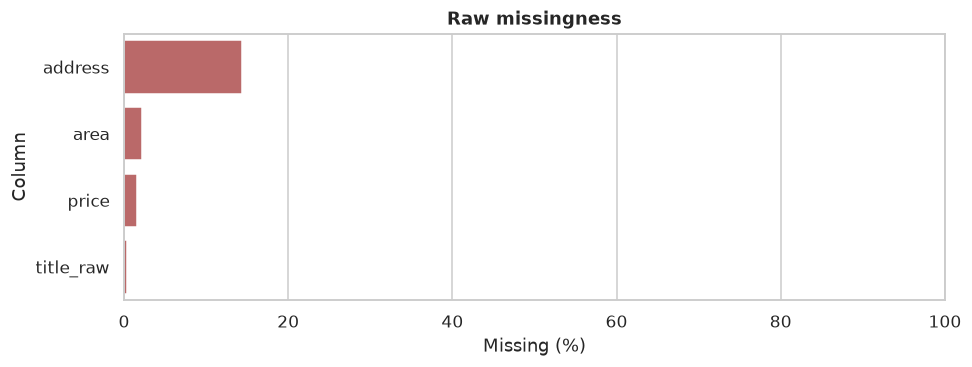

In [82]:
missing_to_plot = missing_audit.query("missing_count > 0").reset_index(names="column")
if not missing_to_plot.empty:
    figure, axis = plt.subplots(figsize=(9, max(3.5, len(missing_to_plot) * 0.4)))
    sns.barplot(data=missing_to_plot, y="column", x="missing_pct", color=PALETTE["raw"], ax=axis)
    axis.set(title="Raw missingness", xlabel="Missing (%)", ylabel="Column", xlim=(0, 100))
    plt.tight_layout()
    plt.show()


### 04.5 Duplicate records


In [83]:
duplicate_listing_count = int(df_raw.duplicated(subset=["rental_post_id"]).sum())
duplicate_exact_count = int(df_raw.duplicated().sum())
display(pd.DataFrame({"check": ["duplicate rental_post_id", "exact duplicate row"], "count": [duplicate_listing_count, duplicate_exact_count]}))


,check,count
0,duplicate rental_post_id,0
1,exact duplicate row,0


### 04.6 Cardinality analysis


In [84]:
cardinality_audit = pd.DataFrame({"unique_values": df_raw.nunique(dropna=True), "unique_ratio_pct": (df_raw.nunique(dropna=True) / len(df_raw) * 100).round(2)})
cardinality_audit = cardinality_audit.sort_values("unique_values", ascending=False)
display(cardinality_audit)


,unique_values,unique_ratio_pct
rental_post_id,47753,100.00
listing_id,47753,100.00
url,47753,100.00
title_raw,46253,96.86
first_observed_at,11002,23.04
observed_at,10954,22.94
last_observed_at,10954,22.94
address,3277,6.86
price,367,0.77
area,207,0.43


### 04.7 Constant and near-constant fields


In [85]:
constant_columns = cardinality_audit.index[cardinality_audit["unique_values"].le(1)].tolist()
top_value_share = df_raw.apply(lambda column: column.value_counts(dropna=False, normalize=True).max()).sort_values(ascending=False)
near_constant_columns = top_value_share.index[top_value_share.ge(0.995)].tolist()
display(pd.DataFrame({"constant_columns": [constant_columns], "near_constant_columns": [near_constant_columns]}))


,constant_columns,near_constant_columns
0,[],[]


### 04.8 Invalid and impossible values


In [86]:
raw_issue_summary = pd.DataFrame(
    {"rule": ["invalid price", "invalid area", "missing/blank address", "missing/blank title"],
     "affected_listings": [
         int((df_raw["price"].notna() & ~df_raw["price"].map(validate_price)).sum()),
         int((df_raw["area"].notna() & ~df_raw["area"].map(validate_area)).sum()),
         int((~raw_presence["address"]).sum()), int((~raw_presence["title"]).sum()),
     ]}
)
raw_issue_summary["affected_pct"] = raw_issue_summary["affected_listings"] / len(df_raw) * 100
display(raw_issue_summary)


,rule,affected_listings,affected_pct
0,invalid price,7,0.01
1,invalid area,352,0.74
2,missing/blank address,6842,14.33
3,missing/blank title,194,0.41


### 04.9 Potential leakage and future-model exclusions


In [87]:
excluded_from_future_model_features = identifier_columns + datetime_columns
leakage_audit = pd.DataFrame({"field": excluded_from_future_model_features, "reason": ["identity / traceability"] * len(identifier_columns) + ["snapshot timestamp"] * len(datetime_columns)})
display(leakage_audit)
print("Target is undefined: no supervised-learning operations are performed.")


,field,reason
0,rental_post_id,identity / traceability
1,listing_id,identity / traceability
2,url,identity / traceability
3,observed_at,snapshot timestamp
4,first_observed_at,snapshot timestamp
5,last_observed_at,snapshot timestamp


Target is undefined: no supervised-learning operations are performed.


### 04.10 Quality summary


In [88]:
quality_audit_summary = pd.DataFrame({"metric": ["rows", "sources", "duplicate listing IDs", "constant fields", "missing price", "missing area", "missing address"], "value": [len(df_raw), df_raw["source"].nunique(), duplicate_listing_count, len(constant_columns), int((~raw_presence["price"]).sum()), int((~raw_presence["area"]).sum()), int((~raw_presence["address"]).sum())]})
display(quality_audit_summary)


,metric,value
0,rows,47753
1,sources,8
2,duplicate listing IDs,0
3,constant fields,0
4,missing price,732
5,missing area,1056
6,missing address,6842


## 05. Exploratory Data Analysis — Before Cleaning


### 05.1 Numerical summary and skewness


In [89]:
raw_numeric_summary = df_raw[["price", "area", "active_days"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
raw_numeric_summary["skew"] = df_raw[["price", "area", "active_days"]].skew(numeric_only=True)
display(raw_numeric_summary)


,count,mean,std,min,1%,25%,50%,75%,99%,max,skew
price,"47,021.00","4,459,064.41","43,454,753.47","2,500.00","1,000,000.00","3,000,000.00","4,000,000.00","5,000,000.00","10,000,000.00","8,500,000,000.00",175.53
area,"46,697.00",33.68,51.78,1.00,8.00,22.00,28.00,35.00,200.00,"2,040.00",12.93
active_days,"47,753.00",0.51,0.50,0.00,0.00,0.00,1.00,1.00,1.00,1.00,-0.03


### 05.2 Categorical source distribution


In [90]:
source_counts = df_raw["source"].value_counts().sort_values()
source_coverage_before = raw_presence.astype("float64").assign(source=df_raw["source"]).groupby("source", observed=True).mean().mul(100).sort_index()


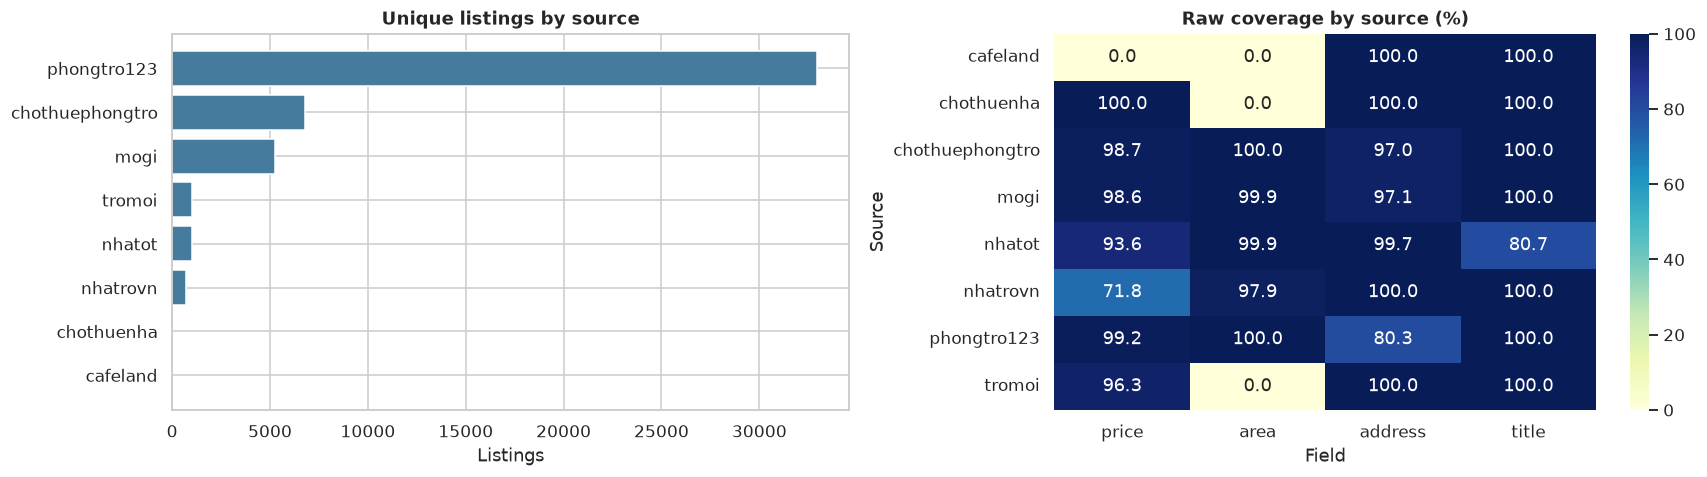

In [91]:
figure, axes = plt.subplots(1, 2, figsize=(16, max(4.5, len(source_counts) * 0.45)))
axes[0].barh(source_counts.index, source_counts.values, color=PALETTE["neutral"])
axes[0].set(title="Unique listings by source", xlabel="Listings")
sns.heatmap(source_coverage_before, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=100, ax=axes[1])
axes[1].set(title="Raw coverage by source (%)", xlabel="Field", ylabel="Source")
plt.tight_layout()
plt.show()


### 05.3 Raw price and area distributions


In [92]:
raw_price_million = df_raw["price"] / 1_000_000
raw_area_m2 = df_raw["area"]
price_limit = finite_quantile(raw_price_million, 0.99)
area_limit = finite_quantile(raw_area_m2, 0.99)


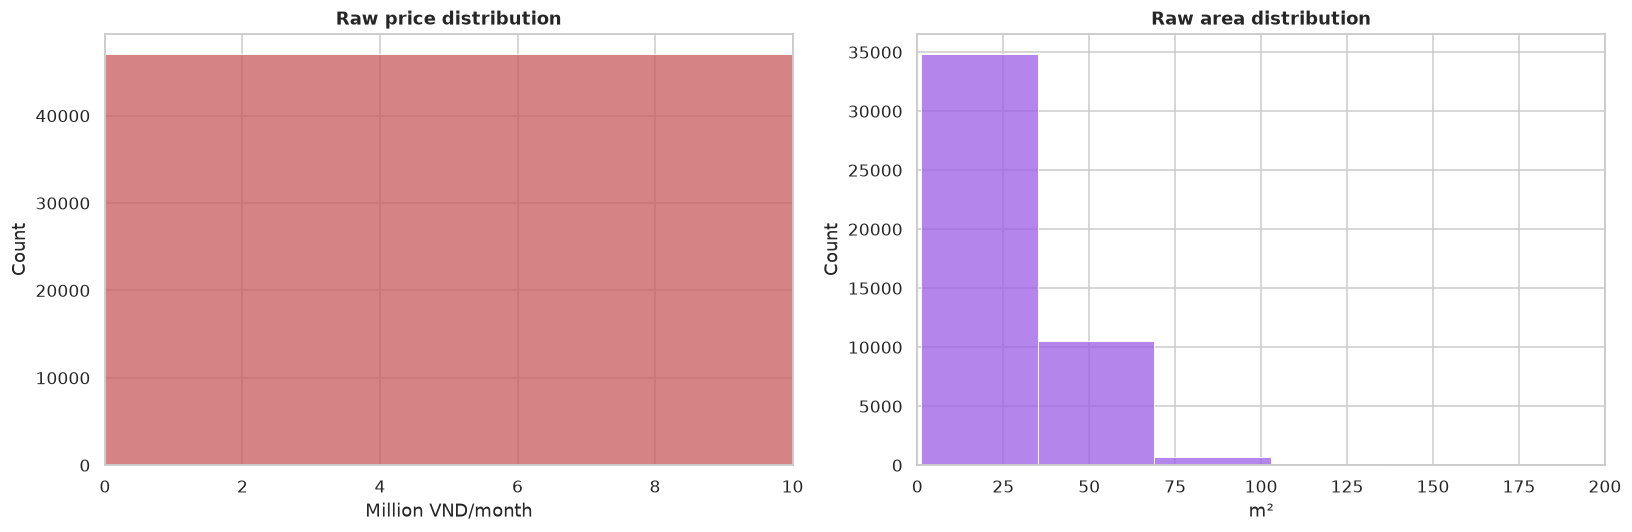

In [93]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(raw_price_million.dropna(), bins=60, color=PALETTE["raw"], ax=axes[0])
axes[0].set(title="Raw price distribution", xlabel="Million VND/month")
sns.histplot(raw_area_m2.dropna(), bins=60, color="#9B5DE5", ax=axes[1])
axes[1].set(title="Raw area distribution", xlabel="m²")
if price_limit is not None: axes[0].set_xlim(0, price_limit)
if area_limit is not None: axes[1].set_xlim(0, area_limit)
plt.tight_layout()
plt.show()


### 05.4 Raw price × area


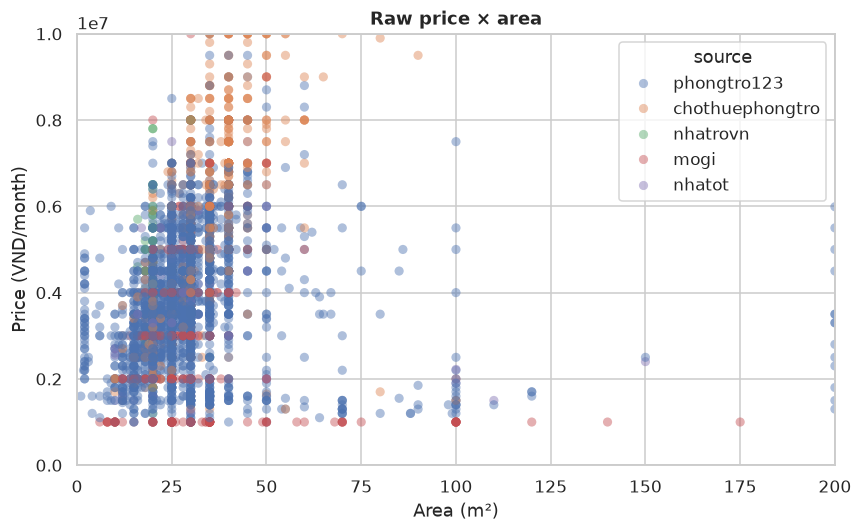

In [94]:
raw_price_area = df_raw.dropna(subset=["price", "area"])
if len(raw_price_area) >= 2:
    figure, axis = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=raw_price_area.sample(min(len(raw_price_area), 5_000), random_state=RANDOM_SEED), x="area", y="price", hue="source", alpha=0.45, linewidth=0, ax=axis)
    axis.set(title="Raw price × area", xlabel="Area (m²)", ylabel="Price (VND/month)")
    axis.set_xlim(0, finite_quantile(raw_price_area["area"], 0.99))
    axis.set_ylim(0, finite_quantile(raw_price_area["price"], 0.99))
    plt.tight_layout()
    plt.show()


### 05.5 Datetime range


In [95]:
raw_time_columns = df_raw[datetime_columns].apply(pd.to_datetime, utc=True, errors="coerce")
time_audit = pd.DataFrame({"min": raw_time_columns.min(), "max": raw_time_columns.max(), "missing": raw_time_columns.isna().sum()})
display(time_audit)


,min,max,missing
observed_at,2026-09-06 10:19:41+00:00,2026-09-07 13:20:17+00:00,0
first_observed_at,2026-09-06 10:19:35+00:00,2026-09-07 13:20:10+00:00,0
last_observed_at,2026-09-06 10:19:41+00:00,2026-09-07 13:20:17+00:00,0


### 05.6 Finding: Question → Evidence → Insight → Decision


In [96]:
price_skew = raw_price_million.dropna().skew()
invalid_price_count = int((df_raw["price"].notna() & ~df_raw["price"].map(validate_price)).sum())
display(Markdown(f"**Question:** Can raw price be used directly?<br>**Evidence:** skewness = `{price_skew:.2f}`; invalid price rows = `{invalid_price_count:,}`.<br>**Insight:** raw values may be distorted by non-plausible records.<br>**Decision:** retain raw for audit and create `price_clean_vnd` for downstream EDA."))


**Question:** Can raw price be used directly?<br>**Evidence:** skewness = `175.53`; invalid price rows = `7`.<br>**Insight:** raw values may be distorted by non-plausible records.<br>**Decision:** retain raw for audit and create `price_clean_vnd` for downstream EDA.

## 06. Data Cleaning


### 06.1 Versioned cleaning rules


In [97]:
cleaning_rules = pd.DataFrame(
    [("price_clean_vnd", f"{MIN_PRICE_VND:,.0f} ≤ price ≤ {MAX_PRICE_VND:,.0f} VND/month", "invalid → NA"),
     ("area_clean_m2", f"{MIN_AREA_M2:g} ≤ area ≤ {MAX_AREA_M2:,.0f} m²", "invalid → NA"),
     ("address_clean", "trim and standardize address formatting", "blank → NA"),
     ("current_location", "exactly one normalized location candidate", "ambiguous → NA")],
    columns=["output_column", "rule", "treatment"],
)
display(cleaning_rules)


,output_column,rule,treatment
0,price_clean_vnd,"300,000 ≤ price ≤ 200,000,000 VND/month",invalid → NA
1,area_clean_m2,"5 ≤ area ≤ 1,000 m²",invalid → NA
2,address_clean,trim and standardize address formatting,blank → NA
3,current_location,exactly one normalized location candidate,ambiguous → NA


### 06.2 Create auditable working copy


In [98]:
df_quality = df_raw.copy(deep=True)
df_quality["cleaning_rule_version"] = CLEANING_RULE_VERSION


### 06.3 Clean numeric fields


In [99]:
df_quality["price_is_valid"] = df_quality["price"].map(validate_price)
df_quality["area_is_valid"] = df_quality["area"].map(validate_area)
df_quality["price_clean_vnd"] = df_quality["price"].where(df_quality["price_is_valid"]).astype("Float64")
df_quality["area_clean_m2"] = df_quality["area"].where(df_quality["area_is_valid"]).astype("Float64")
df_quality["price_million_vnd"] = df_quality["price_clean_vnd"] / 1_000_000


### 06.4 Standardize address text


In [100]:
df_quality["address_clean"] = df_quality["address"].map(clean_address).astype("string")
df_quality["address_is_present"] = non_empty(df_quality["address_clean"])


### 06.5 Normalize location conservatively


In [101]:
df_quality["location_candidates"] = df_quality["address_clean"].map(normalize_location)
df_quality["location_candidate_count"] = df_quality["location_candidates"].map(len)
df_quality["location_mapping_status"] = np.select(
    [df_quality["address_clean"].isna(), df_quality["location_candidate_count"].eq(0), df_quality["location_candidate_count"].eq(1)],
    ["missing_address", "unmatched", "mapped"], default="ambiguous",
)
df_quality["current_location"] = df_quality["location_candidates"].map(lambda candidates: candidates[0] if len(candidates) == 1 else pd.NA).astype("string")


### 06.6 Build row-preserving clean dataset


In [102]:
clean_base_columns = ["source", "rental_post_id", "listing_id", "title_raw", "url", "price", "area", "address", "price_is_valid", "area_is_valid", "price_clean_vnd", "price_million_vnd", "area_clean_m2", "address_clean", "address_is_present", "current_location", "location_candidate_count", "location_mapping_status", "full_address_inherited", "observed_at", "first_observed_at", "last_observed_at", "active_days", "cleaning_rule_version"]
clean_base_columns.extend(column for column in ("latitude", "longitude") if column in df_quality.columns)
df_clean = df_quality.loc[:, list(dict.fromkeys(clean_base_columns))].copy()
assert len(df_clean) == len(df_raw), "Cleaning must preserve every listing row."


### 06.7 Before/after coverage table


In [103]:
quality_comparison = pd.DataFrame({"metric": ["price", "area", "address", "single location mapping"], "before_present": [raw_presence["price"].sum(), raw_presence["area"].sum(), raw_presence["address"].sum(), 0], "after_trusted": [df_clean["price_clean_vnd"].notna().sum(), df_clean["area_clean_m2"].notna().sum(), df_clean["address_clean"].notna().sum(), df_clean["current_location"].notna().sum()]})
quality_comparison["before_pct"] = quality_comparison["before_present"] / len(df_raw) * 100
quality_comparison["after_pct"] = quality_comparison["after_trusted"] / len(df_raw) * 100
display(quality_comparison)


,metric,before_present,after_trusted,before_pct,after_pct
0,price,47021,47014,98.47,98.45
1,area,46697,46345,97.79,97.05
2,address,40911,40911,85.67,85.67
3,single location mapping,0,5887,0.00,12.33


### 06.8 Before/after coverage chart


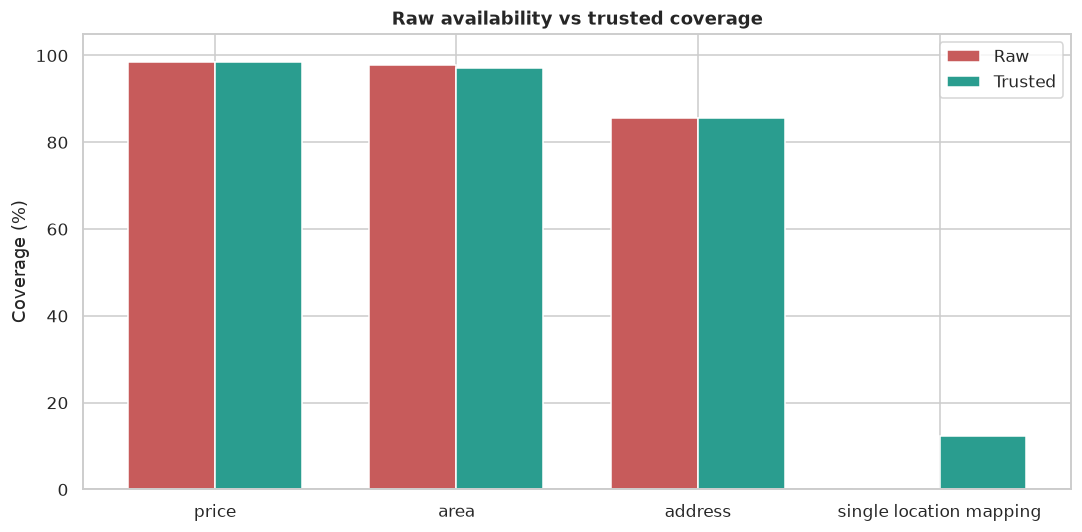

In [104]:
figure, axis = plt.subplots(figsize=(10, 5))
positions, width = np.arange(len(quality_comparison)), 0.36
axis.bar(positions - width / 2, quality_comparison["before_pct"], width, label="Raw", color=PALETTE["raw"])
axis.bar(positions + width / 2, quality_comparison["after_pct"], width, label="Trusted", color=PALETTE["clean"])
axis.set(xticks=positions, xticklabels=quality_comparison["metric"], ylabel="Coverage (%)", ylim=(0, 105), title="Raw availability vs trusted coverage")
axis.legend()
plt.tight_layout()
plt.show()


### 06.9 Before/after distributions


In [105]:
clean_price_million = df_clean["price_million_vnd"].dropna()
clean_area_m2 = df_clean["area_clean_m2"].dropna()


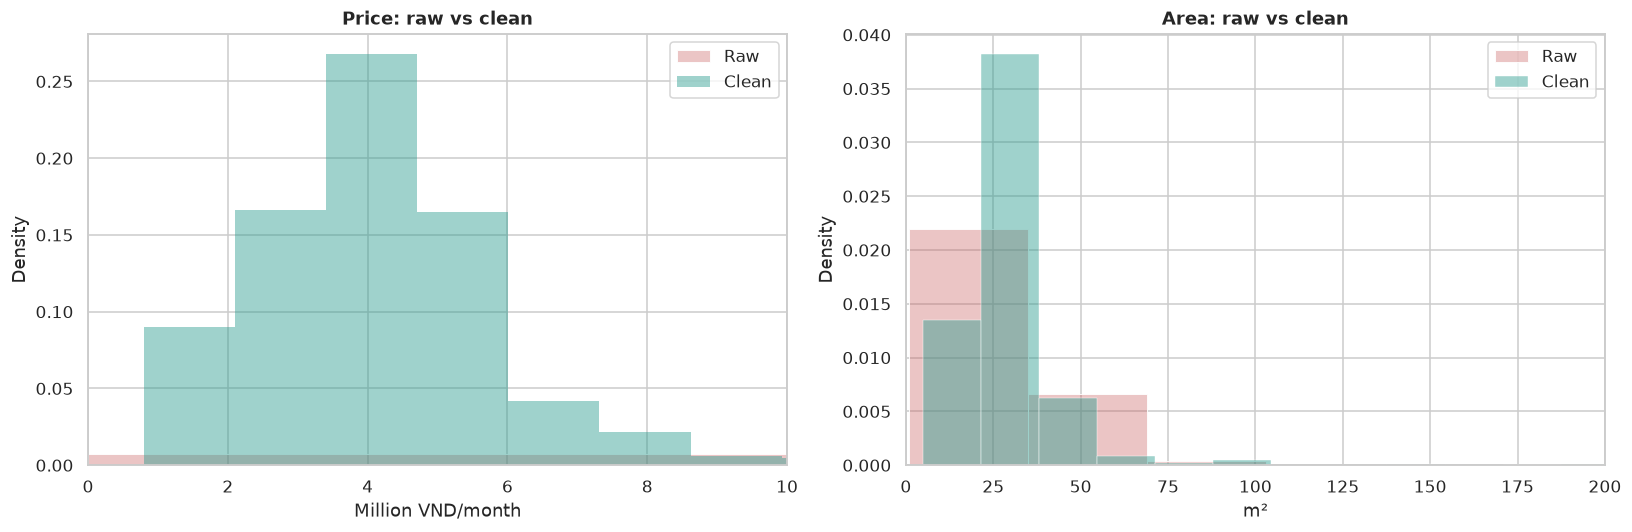

In [106]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, raw_values, clean_values, title, xlabel, limit in [(axes[0], raw_price_million, clean_price_million, "Price", "Million VND/month", price_limit), (axes[1], raw_area_m2, clean_area_m2, "Area", "m²", area_limit)]:
    sns.histplot(raw_values.dropna(), bins=60, stat="density", alpha=0.35, color=PALETTE["raw"], label="Raw", ax=axis)
    sns.histplot(clean_values, bins=60, stat="density", alpha=0.45, color=PALETTE["clean"], label="Clean", ax=axis)
    axis.set(title=f"{title}: raw vs clean", xlabel=xlabel)
    axis.legend()
    if limit is not None: axis.set_xlim(0, limit)
plt.tight_layout()
plt.show()


### 06.10 Trusted coverage by source


In [107]:
source_quality_after = df_clean.assign(price_trusted=df_clean["price_clean_vnd"].notna(), area_trusted=df_clean["area_clean_m2"].notna(), address_trusted=df_clean["address_clean"].notna(), location_mapped=df_clean["current_location"].notna()).groupby("source", observed=True)[["price_trusted", "area_trusted", "address_trusted", "location_mapped"]].mean().mul(100).sort_index()
display(source_quality_after.round(1))


,price_trusted,area_trusted,address_trusted,location_mapped
source,,,,
cafeland,0.00,0.00,100.00,0.00
chothuenha,100.00,0.00,100.00,80.00
chothuephongtro,98.60,100.00,97.00,13.70
mogi,98.60,99.90,97.10,20.20
nhatot,93.30,99.70,99.70,67.70
nhatrovn,71.80,97.80,100.00,66.60
phongtro123,99.20,98.90,80.30,7.30
tromoi,96.30,0.00,100.00,30.50


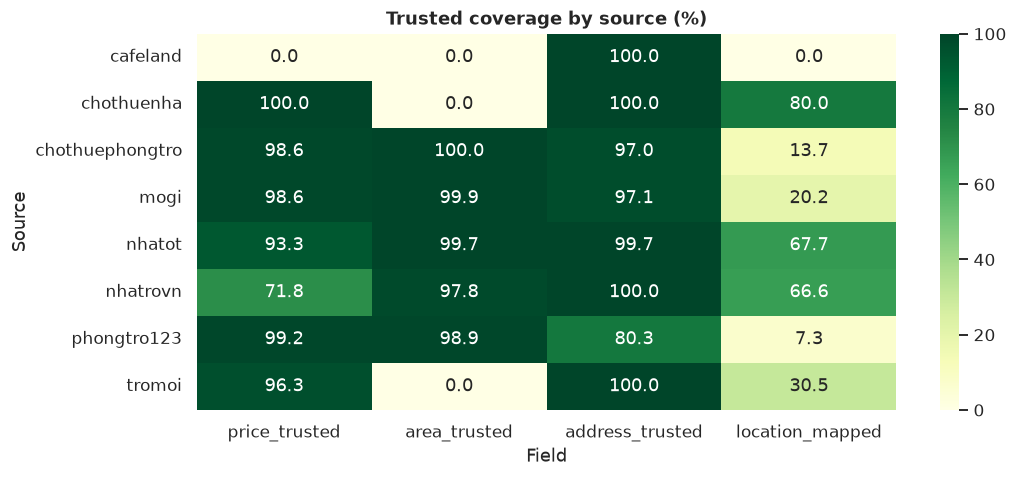

In [108]:
figure, axis = plt.subplots(figsize=(10, max(4.5, len(source_quality_after) * 0.45)))
sns.heatmap(source_quality_after, annot=True, fmt=".1f", cmap="YlGn", vmin=0, vmax=100, ax=axis)
axis.set(title="Trusted coverage by source (%)", xlabel="Field", ylabel="Source")
plt.tight_layout()
plt.show()


### 06.11 Cleaning boundary validation


In [109]:
assert len(df_clean) == len(df_raw)
assert "price_clean_vnd" not in df_raw.columns
assert not df_clean.loc[~df_clean["price_is_valid"], "price_clean_vnd"].notna().any()
assert not df_clean.loc[~df_clean["area_is_valid"], "area_clean_m2"].notna().any()
print("✓ Cleaning is row-preserving and raw data remains unchanged")


✓ Cleaning is row-preserving and raw data remains unchanged


## 07. Exploratory Data Analysis — After Cleaning


### 07.1 Define the clean analytical subset


In [110]:
df_market_clean = df_clean.loc[df_clean["price_clean_vnd"].notna() & df_clean["area_clean_m2"].notna()].copy()
print(f"Market-ready subset: {len(df_market_clean):,} / {len(df_clean):,} listings ({len(df_market_clean) / len(df_clean):.1%})")


Market-ready subset: 45,652 / 47,753 listings (95.6%)


### 07.2 Clean numeric summary


In [111]:
clean_numeric_summary = df_market_clean[["price_million_vnd", "area_clean_m2"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
clean_numeric_summary["skew"] = df_market_clean[["price_million_vnd", "area_clean_m2"]].skew(numeric_only=True)
display(clean_numeric_summary)


,count,mean,std,min,1%,25%,50%,75%,99%,max,skew
price_million_vnd,"45,652.00",4.18,2.00,0.80,1.00,3.00,4.00,5.00,10.00,79.00,5.89
area_clean_m2,"45,652.00",33.66,49.88,5.00,10.00,24.00,28.00,35.00,200.00,"1,000.00",11.89


### 07.3 Clean price × area


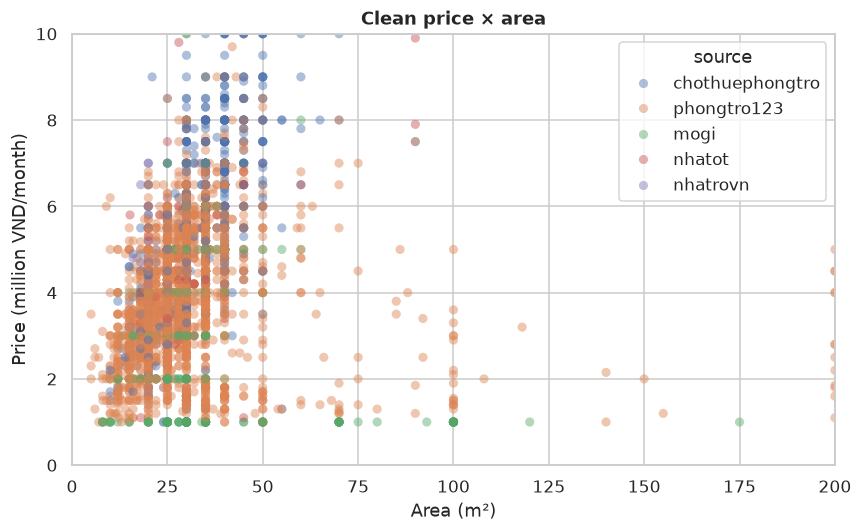

In [112]:
if len(df_market_clean) >= 2:
    figure, axis = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_market_clean.sample(min(len(df_market_clean), 5_000), random_state=RANDOM_SEED), x="area_clean_m2", y="price_million_vnd", hue="source", alpha=0.45, linewidth=0, ax=axis)
    axis.set(title="Clean price × area", xlabel="Area (m²)", ylabel="Price (million VND/month)")
    axis.set_xlim(0, finite_quantile(df_market_clean["area_clean_m2"], 0.99))
    axis.set_ylim(0, finite_quantile(df_market_clean["price_million_vnd"], 0.99))
    plt.tight_layout()
    plt.show()


### 07.4 Clean source comparison


In [113]:
clean_source_summary = df_market_clean.groupby("source", observed=True).agg(listings=("rental_post_id", "nunique"), median_price_million=("price_million_vnd", "median"), median_area_m2=("area_clean_m2", "median")).sort_values("median_price_million", ascending=False).reset_index()
display(clean_source_summary)


,source,listings,median_price_million,median_area_m2
0,chothuephongtro,6707,5.80,35.00
1,nhatrovn,508,4.50,20.00
2,phongtro123,32324,3.90,26.00
3,nhatot,933,3.70,25.00
4,mogi,5180,3.00,30.00


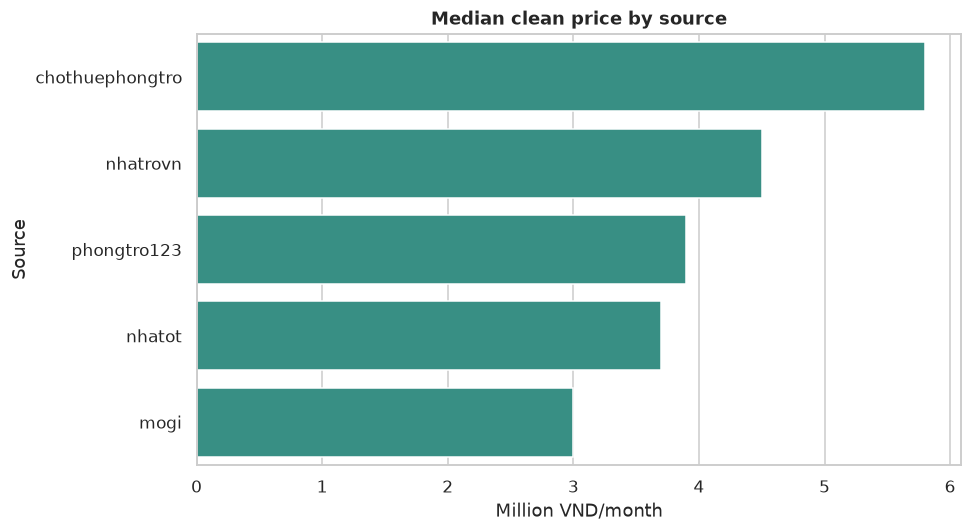

In [114]:
if not clean_source_summary.empty:
    figure, axis = plt.subplots(figsize=(9, 5))
    sns.barplot(data=clean_source_summary, y="source", x="median_price_million", color=PALETTE["clean"], ax=axis)
    axis.set(title="Median clean price by source", xlabel="Million VND/month", ylabel="Source")
    plt.tight_layout()
    plt.show()


### 07.5 Clean location distribution


In [115]:
location_summary = df_clean.dropna(subset=["current_location"]).groupby("current_location", observed=True).agg(listings=("rental_post_id", "nunique"), median_price_million=("price_million_vnd", "median")).sort_values("listings", ascending=False).head(15).reset_index()
display(location_summary)


,current_location,listings,median_price_million
0,Phường Tân Mỹ,3011,3.50
1,Phường Phú Thạnh,575,4.10
2,Phường Tân Hưng,139,4.60
3,Phường Đông Hưng Thuận,110,3.10
4,Phường Tân Bình,100,4.00
5,Phường Trung Mỹ Tây,84,3.00
6,Phường An Nhơn,83,4.00
7,Phường Thạnh Mỹ Tây,74,5.00
8,Phường Bình Lợi Trung,71,4.80
9,Phường Thông Tây Hội,67,3.95


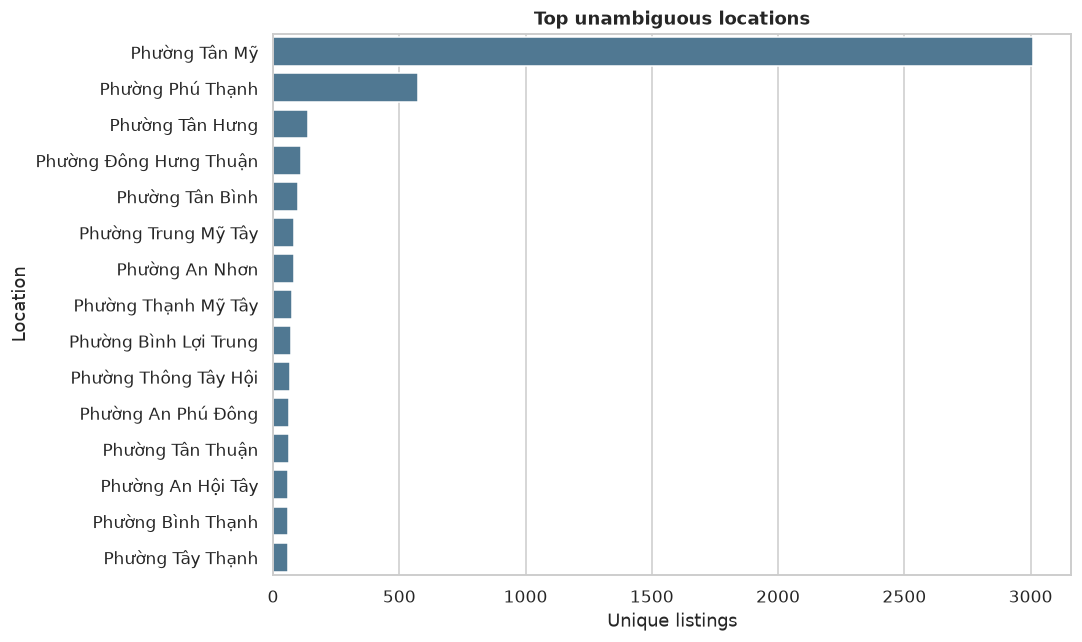

In [116]:
if not location_summary.empty:
    figure, axis = plt.subplots(figsize=(10, 6))
    sns.barplot(data=location_summary, y="current_location", x="listings", color=PALETTE["neutral"], ax=axis)
    axis.set(title="Top unambiguous locations", xlabel="Unique listings", ylabel="Location")
    plt.tight_layout()
    plt.show()


### 07.6 Finding: Question → Evidence → Insight → Decision


In [117]:
trusted_price_coverage = df_clean["price_clean_vnd"].notna().mean()
market_subset_coverage = len(df_market_clean) / len(df_clean)
display(Markdown(f"**Question:** Does clean EDA represent the full snapshot?<br>**Evidence:** market-ready subset = `{market_subset_coverage:.1%}`; trusted price coverage = `{trusted_price_coverage:.1%}`.<br>**Insight:** clean statistics describe the reliable subset, not missing values.<br>**Decision:** report coverage alongside every market-ready result."))


**Question:** Does clean EDA represent the full snapshot?<br>**Evidence:** market-ready subset = `95.6%`; trusted price coverage = `98.5%`.<br>**Insight:** clean statistics describe the reliable subset, not missing values.<br>**Decision:** report coverage alongside every market-ready result.

## 08. Feature Engineering


### 08.1 Start from validated clean data


In [118]:
df_features = df_clean.copy(deep=True)
print(f"Feature input rows: {len(df_features):,}")


Feature input rows: 47,753


### 08.2 Datetime features


In [119]:
for timestamp_column in datetime_columns:
    df_features[timestamp_column] = pd.to_datetime(df_features[timestamp_column], utc=True, errors="coerce")
now_utc = pd.Timestamp.now(tz="UTC")
df_features["listing_age_days"] = (now_utc - df_features["first_observed_at"]).dt.days
df_features["days_since_last_seen"] = (now_utc - df_features["last_observed_at"]).dt.days
df_features["observed_weekday"] = df_features["observed_at"].dt.dayofweek.astype("Int64")


### 08.3 Numerical and domain features


In [120]:
df_features["price_per_m2_vnd"] = (df_features["price_clean_vnd"] / df_features["area_clean_m2"]).where(df_features["area_clean_m2"].gt(0))
df_features["price_band"] = df_features["price_million_vnd"].map(classify_price_band)
df_features["area_band"] = df_features["area_clean_m2"].map(classify_area_band)
df_features["has_coordinates"] = df_features.get("latitude", pd.Series(pd.NA, index=df_features.index)).notna() & df_features.get("longitude", pd.Series(pd.NA, index=df_features.index)).notna()
df_features["has_inherited_address"] = df_features["full_address_inherited"].fillna(False).astype(bool)


### 08.4 Data-quality feature


In [121]:
quality_components = ["price_clean_vnd", "area_clean_m2", "address_clean", "title_raw"]
df_features["data_quality_score"] = df_features[quality_components].notna().mean(axis=1).round(2)
display(df_features["data_quality_score"].value_counts(dropna=False).sort_index().to_frame("listings"))


,listings
data_quality_score,
0.25,4
0.50,168
0.75,8835
1.00,38746


### 08.5 Feature registry


In [122]:
feature_registry = pd.DataFrame(
    [("listing_age_days", "numeric", "days since first observation"), ("days_since_last_seen", "numeric", "days since latest observation"), ("observed_weekday", "ordinal", "weekday of latest observation"), ("price_per_m2_vnd", "numeric", "clean price divided by clean area"), ("price_band", "categorical", "band from clean price"), ("area_band", "categorical", "band from clean area"), ("has_coordinates", "boolean", "both coordinates are present"), ("has_inherited_address", "boolean", "latest address inherited from a prior observation"), ("data_quality_score", "numeric", "completeness across four core fields")],
    columns=["feature", "type", "definition"],
)
display(feature_registry)


,feature,type,definition
0,listing_age_days,numeric,days since first observation
1,days_since_last_seen,numeric,days since latest observation
2,observed_weekday,ordinal,weekday of latest observation
3,price_per_m2_vnd,numeric,clean price divided by clean area
4,price_band,categorical,band from clean price
5,area_band,categorical,band from clean area
6,has_coordinates,boolean,both coordinates are present
7,has_inherited_address,boolean,latest address inherited from a prior observation
8,data_quality_score,numeric,completeness across four core fields


### 08.6 Feature validation


In [123]:
numeric_feature_columns = ["listing_age_days", "days_since_last_seen", "price_per_m2_vnd", "data_quality_score"]
infinite_feature_counts = {column: int(np.isinf(pd.to_numeric(df_features[column], errors="coerce")).sum()) for column in numeric_feature_columns}
feature_validation = pd.DataFrame({"feature": numeric_feature_columns, "missing": [int(df_features[column].isna().sum()) for column in numeric_feature_columns], "infinite": [infinite_feature_counts[column] for column in numeric_feature_columns]})
display(feature_validation)
assert not any(infinite_feature_counts.values())


,feature,missing,infinite
0,listing_age_days,0,0
1,days_since_last_seen,0,0
2,price_per_m2_vnd,2101,0
3,data_quality_score,0,0


## 09. Feature-ready Handoff


### 09.1 Modeling boundary

The target is undefined. Any imputer, encoder, scaler, model-based feature selection or split must be
designed and fit in a separate modeling notebook after an approved target and leakage policy exist.


### 09.2 Build the feature-ready dataset


In [124]:
handoff_columns = ["source", "rental_post_id", "listing_id", "url", "cleaning_rule_version", "price_clean_vnd", "price_million_vnd", "area_clean_m2", "address_clean", "current_location", "listing_age_days", "days_since_last_seen", "observed_weekday", "price_per_m2_vnd", "price_band", "area_band", "has_coordinates", "has_inherited_address", "data_quality_score"]
df_feature_ready = df_features.loc[:, handoff_columns].copy()
assert len(df_feature_ready) == len(df_raw)
display(df_feature_ready.head(3))


,source,rental_post_id,listing_id,url,cleaning_rule_version,price_clean_vnd,price_million_vnd,area_clean_m2,address_clean,current_location,listing_age_days,days_since_last_seen,observed_weekday,price_per_m2_vnd,price_band,area_band,has_coordinates,has_inherited_address,data_quality_score
0,nhatot,21832,129798980,https://www.nhatot.com/thue-phong-tro-thanh-ph...,eda-prep-v1.0,"1,300,000.00",1.30,30.00,"KDC Him Lam Phú Đông, Số 19 Đường D, Phường Li...",<NA>,1,0,0,"43,333.33",< 2 triệu,30–50 m²,False,False,1.00
1,nhatot,21821,134530642,https://www.nhatot.com/thue-phong-tro-quan-go-...,eda-prep-v1.0,"3,200,000.00",3.20,20.00,"Đường Lê Văn Thọ, Phường 9, Quận Gò Vấp, Tp Hồ...",<NA>,1,0,0,"160,000.00",2–5 triệu,20–30 m²,False,False,1.00
2,nhatot,106808,133424510,https://www.nhatot.com/thue-phong-tro-quan-7-t...,eda-prep-v1.0,"4,500,000.00",4.50,20.00,"9A, Phường Tân Hưng, Quận 7, Tp Hồ Chí Minh",Phường Tân Hưng,0,0,0,"225,000.00",2–5 triệu,20–30 m²,False,False,1.00


### 09.3 Post-processing validation


In [125]:
handoff_numeric = ["listing_age_days", "days_since_last_seen", "price_per_m2_vnd", "data_quality_score"]
handoff_checks = pd.DataFrame({"check": ["row conservation", "unique rental_post_id", "infinite numeric feature", "target defined"], "result": [len(df_feature_ready) == len(df_raw), df_feature_ready["rental_post_id"].is_unique, not np.isinf(df_feature_ready[handoff_numeric].select_dtypes(include=[np.number])).any().any(), target_column is not None]})
display(handoff_checks)
assert handoff_checks.loc[handoff_checks["check"] != "target defined", "result"].all()


,check,result
0,row conservation,True
1,unique rental_post_id,True
2,infinite numeric feature,True
3,target defined,False


### 09.4 Optional local export


In [126]:
WRITE_FEATURE_EXPORT = False
if WRITE_FEATURE_EXPORT:
    export_directory = PROJECT_ROOT / "data" / "exports" / "eda"
    export_directory.mkdir(parents=True, exist_ok=True)
    export_timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    export_path = export_directory / f"roombeacon_feature_ready_{CLEANING_RULE_VERSION}_{export_timestamp}.parquet"
    df_feature_ready.to_parquet(export_path, index=False, engine="pyarrow")
    print(f"Exported {len(df_feature_ready):,} rows to {export_path}")
else:
    print("Export is disabled. Enable it only after reviewing the audit and EDA evidence.")


Export is disabled. Enable it only after reviewing the audit and EDA evidence.


## 10. Conclusions & Next Engineering Work

This notebook supplies reproducible evidence and an auditable handoff. Promote rules into the production
pipeline only after fixtures, tests and versioned rule definitions are approved. The next artifact is a
modeling design that defines target, split strategy, train-only preprocessing and evaluation criteria.
